# Amazon Review Intelligence Pipeline — Exploration Notebook

Interactive exploration of the Amazon Beauty reviews dataset,
sentiment scoring results, and divergence analysis output.

## Section 1 — Setup & Imports

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from google.cloud import bigquery
from huggingface_hub import login
from IPython.display import display
from pathlib import Path

env_path = Path(".env") if Path(".env").exists() \
    else Path("../.env")
load_dotenv(dotenv_path=env_path)

HF_TOKEN = os.getenv("HF_TOKEN")
GCP_PROJECT = os.getenv("GCP_PROJECT")
BQ_DATASET = os.getenv("BQ_DATASET")
BQ_TABLE = os.getenv("BQ_TABLE")

login(token=HF_TOKEN)

client = bigquery.Client(project=GCP_PROJECT)
print("Setup complete.")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Setup complete.


## Section 2 — Load & Verify Data

In [2]:
outputs_dir = Path("outputs") if Path("outputs").exists() else Path("../outputs")
cache_path = outputs_dir / "raw_reviews_cache.csv"

if os.path.exists(cache_path):
    df = pd.read_csv(cache_path)
    if "timestamp" in df.columns:
        df["timestamp"] = pd.to_datetime(
            df["timestamp"], errors="coerce"
        )
    print("Loaded from local cache.")
else:
    print("Cache not found. Run pipeline.py first.")
    df = pd.DataFrame()

if not df.empty:
    print(f"Shape: {df.shape}")
    print(f"\nDtypes:\n{df.dtypes}")
    print(f"\nFirst 5 rows:")
    display(df.head())
    print(f"\nNull counts per column:")
    print(df.isnull().sum())

Loaded from local cache.
Shape: (500000, 10)

Dtypes:
rating                      float64
title                        object
text                         object
images                       object
asin                         object
parent_asin                  object
user_id                      object
timestamp            datetime64[ns]
helpful_vote                  int64
verified_purchase              bool
dtype: object

First 5 rows:


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5.0,Such a lovely scent but not overpowering.,This spray is really nice. It smells really go...,[],B00YQ6X8EO,B00YQ6X8EO,AGKHLEW2SOWHNMFQIJGBECAF7INQ,1970-01-01 00:26:28.687728923,0,True
1,4.0,Works great but smells a little weird.,"This product does what I need it to do, I just...",[],B081TJ8YS3,B081TJ8YS3,AGKHLEW2SOWHNMFQIJGBECAF7INQ,1970-01-01 00:26:28.615855070,1,True
2,5.0,Yes!,"Smells good, feels great!",[],B07PNNCSP9,B097R46CSY,AE74DYR3QUGVPZJ3P7RFWBGIX7XQ,1970-01-01 00:26:29.665266052,2,True
3,1.0,Synthetic feeling,Felt synthetic,[],B09JS339BZ,B09JS339BZ,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,1970-01-01 00:27:23.393630220,0,True
4,5.0,A+,Love it,[],B08BZ63GMJ,B08BZ63GMJ,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,1970-01-01 00:26:49.322563534,0,True



Null counts per column:


rating                 0
title                104
text                 121
images                 0
asin                   0
parent_asin            0
user_id                0
timestamp              0
helpful_vote           0
verified_purchase      0
dtype: int64


## Section 3 — EDA

In [3]:
if not df.empty:
    print("Descriptive statistics (numeric columns):")
    display(df.describe())

    print("\nRating value counts:")
    print(df["rating"].value_counts().sort_index())

    print("\nTop 10 most reviewed parent_asins:")
    top_asins = df["parent_asin"].value_counts().head(10)
    print(top_asins)

Descriptive statistics (numeric columns):


,rating,timestamp,helpful_vote
count,500000.000000,500000,500000.000000
mean,4.001812,1970-01-01 00:25:53.932581566,0.931854
min,1.000000,1970-01-01 00:16:20.874814,0.000000
25%,3.000000,1970-01-01 00:25:01.123927940,0.000000
50%,5.000000,1970-01-01 00:26:09.430346709,0.000000
75%,5.000000,1970-01-01 00:26:53.647963731,1.000000
max,5.000000,1970-01-01 00:28:04.021832795,646.000000
std,1.456105,NaN,5.573741



Rating value counts:


rating
1.0     65783
2.0     30920
3.0     42149
4.0     58904
5.0    302244
Name: count, dtype: int64

Top 10 most reviewed parent_asins:


parent_asin
B085BB7B1M    1954
B09X9BG4FC    1358
B0BM4GX6TT    1280
B01M1OFZOG    1206
B07C533XCW     997
B00R1TAN7I     981
B019GBG0IE     969
B07ZJKVVLW     837
B0107QYW14     833
B01N4885PD     740
Name: count, dtype: int64


## Section 4 — BigQuery Confirmation

In [4]:
try:
    raw_q = f"""SELECT COUNT(*) AS row_count 
        FROM `{GCP_PROJECT}.{BQ_DATASET}.{BQ_TABLE}`"""
    raw_result = client.query(raw_q).to_dataframe()
    print(f"raw_reviews: "
          f"{raw_result['row_count'].iloc[0]:,} rows")
except Exception as e:
    print(f"raw_reviews not found. "
          f"Run pipeline.py first.\nError: {e}")

try:
    sent_q = f"""SELECT COUNT(*) AS row_count 
        FROM `{GCP_PROJECT}.{BQ_DATASET}`
        .`reviews_with_sentiment`"""
    sent_result = client.query(sent_q).to_dataframe()
    print(f"reviews_with_sentiment: "
          f"{sent_result['row_count'].iloc[0]:,} rows")
except Exception as e:
    print(f"reviews_with_sentiment not found. "
          f"Run sentiment_scoring.py first.\nError: {e}")

C:\Users\AthxngBachhav\amazon-reviews-analytics+\.venv\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


raw_reviews: 481,156 rows


reviews_with_sentiment: 100,096 rows


## Section 5 — Divergence Results

In [5]:
outputs_dir = Path("outputs") if \
    Path("outputs").exists() else Path("../outputs")
divergence_path = outputs_dir / "divergence_results.csv"

if os.path.exists(divergence_path):
    div_df = pd.read_csv(divergence_path)
    print(f"Divergence results shape: {div_df.shape}")

    print("\nTop 20 products by divergence_magnitude:")
    display(div_df.nlargest(20, "divergence_magnitude"))

    print("\nRisk tier distribution:")
    print(div_df["risk_tier"].value_counts())
else:
    print("Divergence results not found. Run divergence_analysis.py first.")
    div_df = pd.DataFrame()

Divergence results shape: (230, 10)

Top 20 products by divergence_magnitude:


,parent_asin,review_count,avg_star_rating,avg_sentiment_numeric,avg_sentiment_confidence,high_star_negative_sentiment,low_star_positive_sentiment,divergence_pct,divergence_magnitude,risk_tier
0,B0001HYJW2,31,1.871,-1.000,0.949,0,0,0.00,0.3742,LOW RISK
1,B001VPEFPY,31,2.000,-0.935,0.977,0,1,3.23,0.3675,LOW RISK
2,B0067BAIM6,31,2.129,-0.871,0.998,0,1,3.23,0.3613,LOW RISK
3,B000FEF1V4,86,2.209,-0.837,0.968,0,0,0.00,0.3603,LOW RISK
4,B0002SGSNI,33,2.091,-0.879,0.958,0,1,3.03,0.3577,LOW RISK
5,B001FYT87G,44,2.068,-0.818,0.969,0,1,2.27,0.3226,LOW RISK
6,B07Y6WBGQQ,32,2.375,-0.688,0.970,0,1,3.13,0.3190,LOW RISK
7,B0009MFUOA,49,1.980,-0.837,0.982,0,3,6.12,0.3145,LOW RISK
8,B000GBICYE,33,2.152,-0.758,0.971,0,2,6.06,0.3094,LOW RISK
9,B000FEGUIM,33,2.303,-0.697,0.956,0,1,3.03,0.3091,LOW RISK



Risk tier distribution:
risk_tier
LOW RISK       178
MEDIUM RISK     49
HIGH RISK        3
Name: count, dtype: int64


## Section 6 — Visualizations

### Plot 1: Rating Distribution Histogram

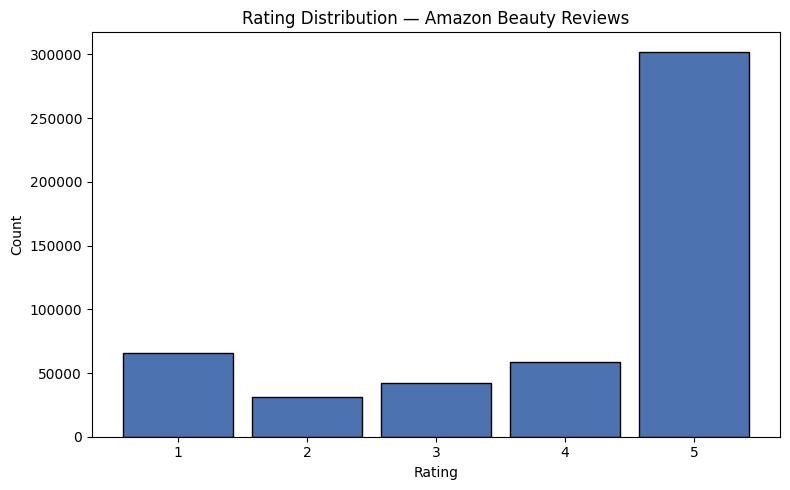

In [6]:
if not df.empty:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(df["rating"], bins=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5],
            edgecolor="black", color="#4C72B0", rwidth=0.85)
    ax.set_xlabel("Rating")
    ax.set_ylabel("Count")
    ax.set_title("Rating Distribution \u2014 Amazon Beauty Reviews")
    ax.set_xticks([1, 2, 3, 4, 5])
    plt.tight_layout()
    plt.show()

### Plot 2: Top 20 Products by Divergence Magnitude

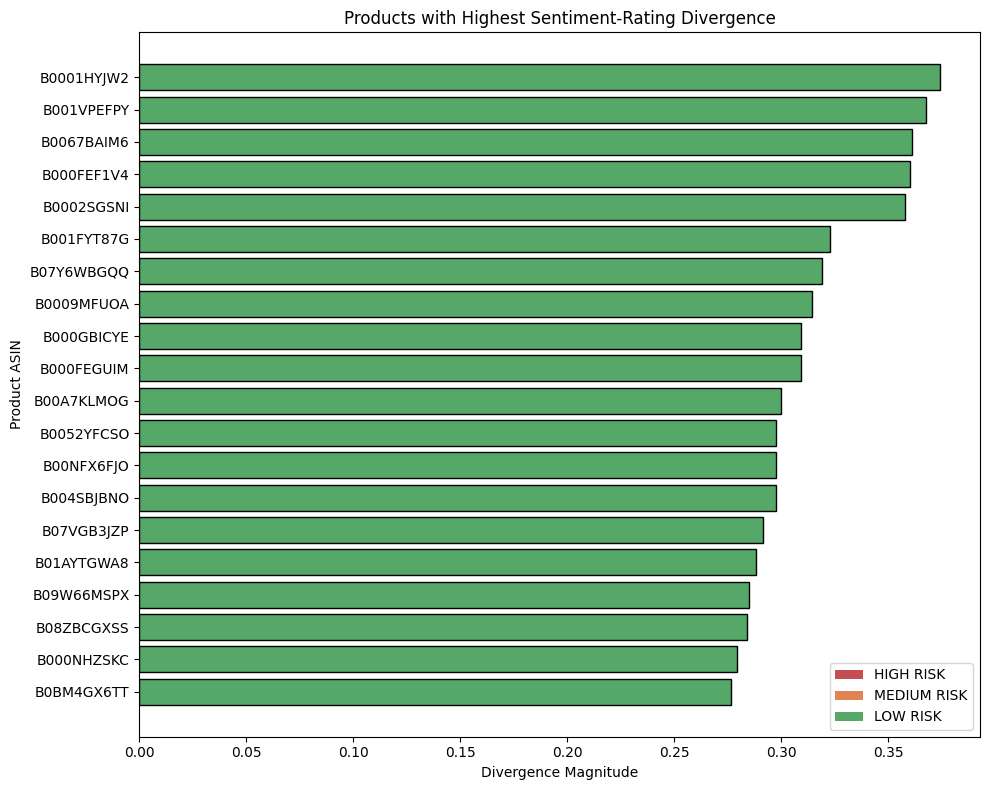

In [7]:
if not div_df.empty:
    top20 = div_df.nlargest(20, "divergence_magnitude")
    color_map = {
        "HIGH RISK": "#C44E52",
        "MEDIUM RISK": "#DD8452",
        "LOW RISK": "#55A868"
    }
    bar_colors = [
        color_map.get(t, "#999999")
        for t in top20["risk_tier"]
    ]
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(
        top20["parent_asin"].astype(str),
        top20["divergence_magnitude"],
        color=bar_colors,
        edgecolor="black"
    )
    ax.set_xlabel("Divergence Magnitude")
    ax.set_ylabel("Product ASIN")
    ax.set_title(
        "Products with Highest Sentiment-Rating Divergence"
    )
    ax.invert_yaxis()
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor="#C44E52", label="HIGH RISK"),
        Patch(facecolor="#DD8452", label="MEDIUM RISK"),
        Patch(facecolor="#55A868", label="LOW RISK")
    ]
    ax.legend(handles=legend_elements, loc="lower right")
    plt.tight_layout()
    plt.show()

### Plot 3: Risk Tier Distribution

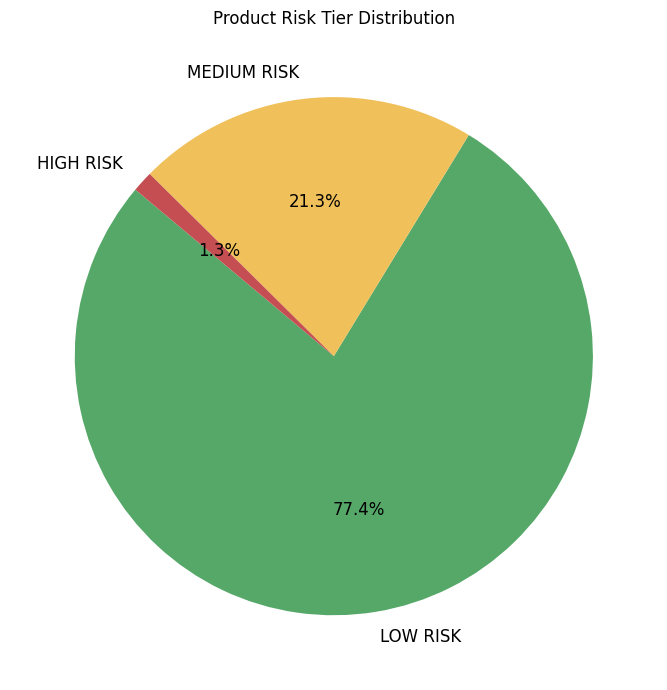

In [8]:
if not div_df.empty:
    risk_counts = div_df["risk_tier"].value_counts()
    colors = {"HIGH RISK": "#C44E52", "MEDIUM RISK": "#F0C05A", "LOW RISK": "#55A868"}
    plot_colors = [colors.get(tier, "#999999") for tier in risk_counts.index]

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.pie(risk_counts.values, labels=risk_counts.index, autopct="%1.1f%%",
           colors=plot_colors, startangle=140, textprops={"fontsize": 12})
    ax.set_title("Product Risk Tier Distribution")
    plt.tight_layout()
    plt.show()

## Section 7 — Gemini Complaint Themes

In [9]:
from pathlib import Path

themes_path = Path("outputs") / \
    "gemini_complaint_themes.csv" \
    if Path("outputs").exists() \
    else Path("../outputs") / \
    "gemini_complaint_themes.csv"

if themes_path.exists():
    themes_df = pd.read_csv(themes_path)
    print(f"Gemini themes shape: {themes_df.shape}")
    print(f"\nProducts processed: "
          f"{themes_df['parent_asin'].nunique()}")
    print(f"Risk tier breakdown:")
    print(themes_df["risk_tier"].value_counts())
    print("\nSample themes — top 5 products "
          "by divergence_magnitude:")
    display(
        themes_df.nlargest(
            5, "divergence_magnitude"
        )[[
            "parent_asin", "risk_tier",
            "divergence_pct", "theme_1",
            "theme_2", "theme_3"
        ]]
    )
else:
    print("Gemini themes not found. "
          "Run gemini_extraction.py first.")

Gemini themes shape: (20, 7)

Products processed: 20
Risk tier breakdown:
risk_tier
MEDIUM RISK    20
Name: count, dtype: int64

Sample themes — top 5 products by divergence_magnitude:


,parent_asin,risk_tier,divergence_pct,theme_1,theme_2,theme_3
0,B000PKKAGO,MEDIUM RISK,13.16,"{'theme_name': 'Poor Shave Quality', 'descript...","{'theme_name': 'Design & Usability Flaws', 'de...",{'theme_name': 'Disappointing Value/Regression...
1,B000G8LWZI,MEDIUM RISK,10.00,"{'theme_name': 'Skin Irritation & Breakouts', ...",{'theme_name': 'Ineffective / Underperforming'...,"{'theme_name': 'Product Discrepancy & Value', ..."
2,B004PZXJUO,MEDIUM RISK,10.00,"{'theme_name': 'Short cooling duration', 'desc...","{'theme_name': 'Smaller than expected', 'descr...","{'theme_name': 'Requires refrigeration', 'desc..."
3,B08DKG8TJJ,MEDIUM RISK,10.87,"{'theme_name': 'Incorrect Sizing & Fit', 'desc...","{'theme_name': 'Poor Stability & Adherence', '...","{'theme_name': 'Flimsy Material & Durability',..."
4,B005V3AV5U,MEDIUM RISK,12.50,"{'theme_name': 'Application & Messiness', 'des...","{'theme_name': 'Poor Finish & Longevity', 'des...","{'theme_name': 'Skin Irritation & Brushes', 'd..."
